# 5.0 Model training - LightGBM - Optuna search


## Imports


In [1]:
import numpy as np
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
    RANDOM_SEED,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.features import GOLDEN_WEEK_FLG
from recruit_restaurant_visitor_forecasting.modeling.train import (
    load_data,
    prepare_features,
    shap_fs,
    lgbm_optuna_search,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred
from recruit_restaurant_visitor_forecasting.utils import (
    merge_daily_pred,
    get_format,
    optuna_cv_results_to_df,
)
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-23 00:22:31.392 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 5
TEST_SIZE = 0.2
FIRST_ITER_TRIALS = 50
SECOND_ITER_TRIALS = 250
USELESS_FEATURES = [
    *[
        VISITORS_NBR_COL + suffix
        for suffix in ["_mean_7", "_mean_14", "_median_7", "_median_28"]
    ],
    GOLDEN_WEEK_FLG,
]
DROP_COLUMNS = [
    AIR_RESTAURANT_ID_COL,
    VISIT_DATE_COL,
    VISITORS_NBR_COL,
    DAY_OF_WEEK_COL,
    CITY_COL,
    *USELESS_FEATURES,
]

FS_VALID_SIZE = 0.2

MODEL_NAME = "lightgbm_optuna"
MODEL_PATH = MODELS_DIR / f"{MODEL_NAME}_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
features = prepare_features(features)
labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [4]:
X = features
y = labels

X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Training

In [5]:
def print_best_params(optuna_study):
    print("Best parameters:", optuna_study.best_params)
    print(f"Best score: {optuna_study.best_value:.5f}")

### Iteration 1

In [6]:
study, model = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=FIRST_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
)
print_best_params(study)

[I 2026-01-18 19:13:38,875] A new study created in memory with name: no-name-6169319e-2df0-429a-a393-a3677e741635
[I 2026-01-18 19:14:02,676] Trial 1 finished with value: 0.9350152281790706 and parameters: {'max_depth': 3, 'learning_rate': 0.006572408124278866, 'n_estimators': 224, 'subsample': 0.6527756365863822, 'colsample_bytree': 0.854293961096227, 'min_child_samples': 17, 'reg_alpha': 0.007419321205355948, 'reg_lambda': 0.8762220903372248, 'num_leaves': 7}. Best is trial 1 with value: 0.9350152281790706.
[I 2026-01-18 19:14:07,954] Trial 0 finished with value: 1.1754201512264943 and parameters: {'max_depth': 4, 'learning_rate': 0.0018923072666966643, 'n_estimators': 107, 'subsample': 0.8593859629180871, 'colsample_bytree': 0.6608842976028357, 'min_child_samples': 11, 'reg_alpha': 0.00017836926016288418, 'reg_lambda': 0.006391077997265866, 'num_leaves': 9}. Best is trial 1 with value: 0.9350152281790706.
[I 2026-01-18 19:14:08,834] Trial 4 finished with value: 0.7209956102511184 an

Best parameters: {'max_depth': 5, 'learning_rate': 0.22143719531279746, 'n_estimators': 152, 'subsample': 0.8214761957262513, 'colsample_bytree': 0.8417970113959816, 'min_child_samples': 13, 'reg_alpha': 0.0012330571399113823, 'reg_lambda': 0.7339738757679659, 'num_leaves': 32}
Best score: 0.69540


In [7]:
optuna_cv_results_to_df(study).sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
48,"{'max_depth': 5, 'learning_rate': 0.2214371953...",0.068632,0.695396,0.762466,0.700261,0.618216,0.617212,0.778823,1
21,"{'max_depth': 5, 'learning_rate': 0.2800881889...",0.065555,0.695997,0.763931,0.704495,0.626337,0.615395,0.769827,2
41,"{'max_depth': 5, 'learning_rate': 0.1403213620...",0.071993,0.701103,0.768199,0.709152,0.621170,0.617045,0.789948,3
10,"{'max_depth': 5, 'learning_rate': 0.2737462320...",0.072166,0.701490,0.776234,0.709319,0.615937,0.622147,0.783811,4
17,"{'max_depth': 5, 'learning_rate': 0.2915187559...",0.075749,0.701507,0.766615,0.702797,0.617863,0.617115,0.803145,5


### SHAP feature selection

In [15]:
selected_features, feature_stats = shap_fs(
    X_train,
    y_train,
    model.named_steps["model"],
    drop_features=DROP_COLUMNS,
    test_size=FS_VALID_SIZE,
)

### Iteration 2

In [16]:
study, model_shap = lgbm_optuna_search(
    X_train,
    y_train,
    n_jobs=6,
    drop_features=DROP_COLUMNS,
    n_trials=SECOND_ITER_TRIALS,
    n_splits=CV_SPLITS,
    random_state=RANDOM_SEED,
    features_top=selected_features,
)
print_best_params(study)

[I 2026-01-18 20:00:25,816] A new study created in memory with name: no-name-6673f27e-6843-4730-bdb9-972171f95ccb
[I 2026-01-18 20:00:41,705] Trial 0 finished with value: 0.94162060589514 and parameters: {'max_depth': 3, 'learning_rate': 0.006636072455373323, 'n_estimators': 222, 'subsample': 0.6567383669894427, 'colsample_bytree': 0.7218780275804367, 'min_child_samples': 18, 'reg_alpha': 0.02024078599583717, 'reg_lambda': 0.0009476100332944245, 'num_leaves': 7, 'keep_count': 11}. Best is trial 0 with value: 0.94162060589514.
[I 2026-01-18 20:00:46,362] Trial 5 finished with value: 1.1482468782475257 and parameters: {'max_depth': 4, 'learning_rate': 0.0022277126781184062, 'n_estimators': 125, 'subsample': 0.5996970116460263, 'colsample_bytree': 0.8345218223099384, 'min_child_samples': 13, 'reg_alpha': 0.026481977334886157, 'reg_lambda': 0.0002505052166689724, 'num_leaves': 14, 'keep_count': 37}. Best is trial 0 with value: 0.94162060589514.
[I 2026-01-18 20:00:47,270] Trial 3 finished 

Best parameters: {'max_depth': 5, 'learning_rate': 0.21773092416877415, 'n_estimators': 298, 'subsample': 0.88242387806211, 'colsample_bytree': 0.9461826364228484, 'min_child_samples': 12, 'reg_alpha': 0.0009510525117879846, 'reg_lambda': 8.052110634552418, 'num_leaves': 29, 'keep_count': 19}
Best score: 0.68279


In [17]:
cv_results = optuna_cv_results_to_df(study)
cv_results.sort_values(["rank_test_score"]).head()

,params,std_test_score,mean_test_score,split_test_0,split_test_1,split_test_2,split_test_3,split_test_4,rank_test_score
240,"{'max_depth': 5, 'learning_rate': 0.2177309241...",0.075307,0.682789,0.763691,0.704642,0.599101,0.589151,0.757362,1
212,"{'max_depth': 5, 'learning_rate': 0.1979804125...",0.070234,0.683066,0.764641,0.708938,0.602736,0.596984,0.742033,2
66,"{'max_depth': 5, 'learning_rate': 0.2256576697...",0.076640,0.683237,0.768483,0.697250,0.600859,0.588261,0.761331,3
241,"{'max_depth': 5, 'learning_rate': 0.2156874598...",0.076141,0.683869,0.778739,0.696540,0.594577,0.598302,0.751187,4
177,"{'max_depth': 5, 'learning_rate': 0.2103481645...",0.075765,0.685804,0.780253,0.690964,0.614608,0.587095,0.756103,5


### Scores

In [18]:
y_train_pred = model_shap.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")

Train set metrics:
RMSLE: 0.8194
MAE:  6.3805


In [6]:
y_test_pred, temp_features = recursive_predict(
    model_shap,
    X_test,
    X_train,
    y_train,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:154: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.90573755e+01 1.30746984e+01 7.46622991e+00 5.72363488e+00
 4.81537664e+00 1.85671863e+01 1.13410685e+01 4.42562419e+01
 3.13360607e+01 7.09275321e+00 2.95872405e+01 3.13740754e+00
 1.77743300e+01 2.57021581e+01 1.53335205e+01 8.81720141e+00
 1.35288424e-01 5.98844130e+00 2.59629033e+00 2.66900150e+01
 1.99051313e+01 4.34993158e+01 5.85379202e+00 1.12868735e+01
 8.91017145e+00 1.56766909e+01 5.62812031e+00 8.61345358e+00
 7.91241369e+00 2.49220422e+01 0.00000000e+00 5.35323724e+01
 2.59476304e+01 5.92173907e+00 6.71773777e-02 2.66711127e+01
 8.21066020e+00 4.92027245e+00 1.07585764e+01 8.79696269e+00
 9.81928417e-01 6.74554323e+00 1.41969727e+01 5.28441585e+00
 1.96889637e-02 1.78338337e+01 8.55243019e+00 3.96535

In [7]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")


Test set metrics:
RMSLE: 0.8315
MAE:  7.1491


## Graphs

## SHAP explanation

In [19]:
X_test_clean = model_shap.named_steps["feature_dropper"].transform(X_test)
lgbm = model_shap.named_steps["model"]

explainer = shap.TreeExplainer(lgbm)
shap_values = explainer(X_test_clean)

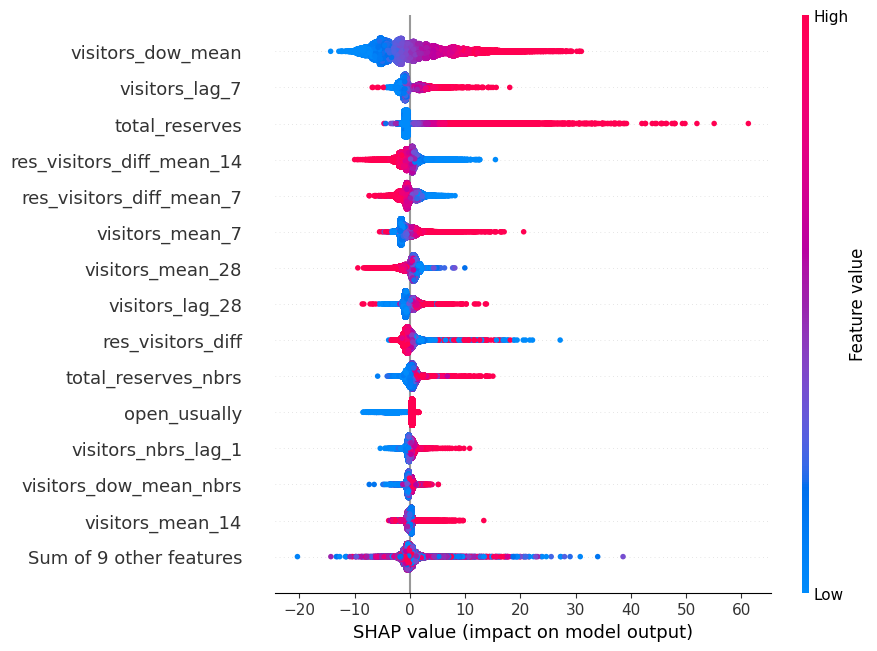

In [20]:
shap.plots.beeswarm(shap_values, max_display=15)

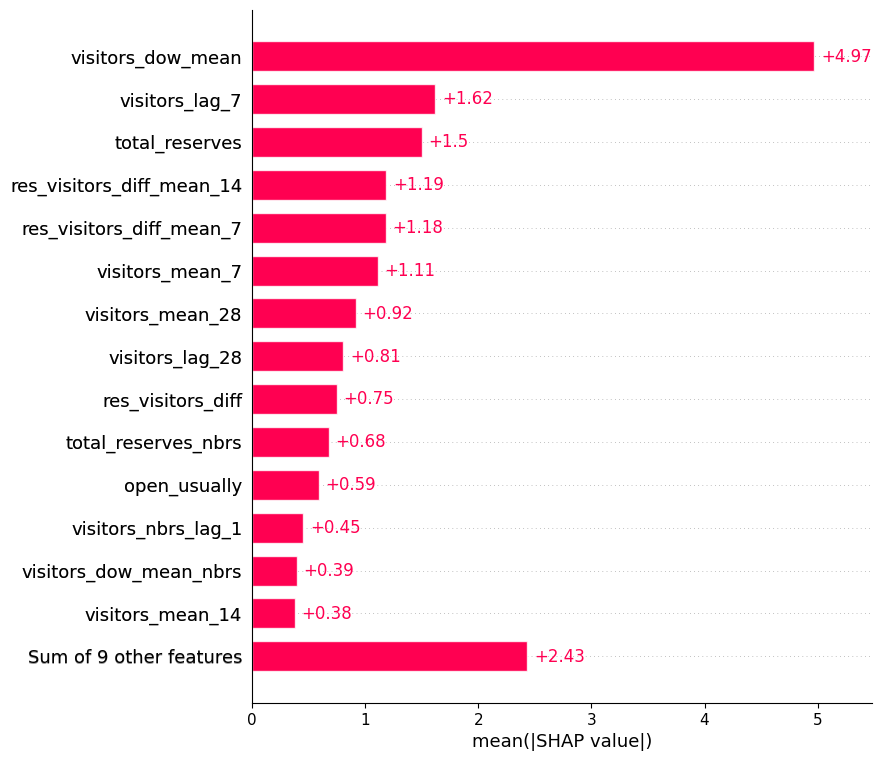

In [21]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

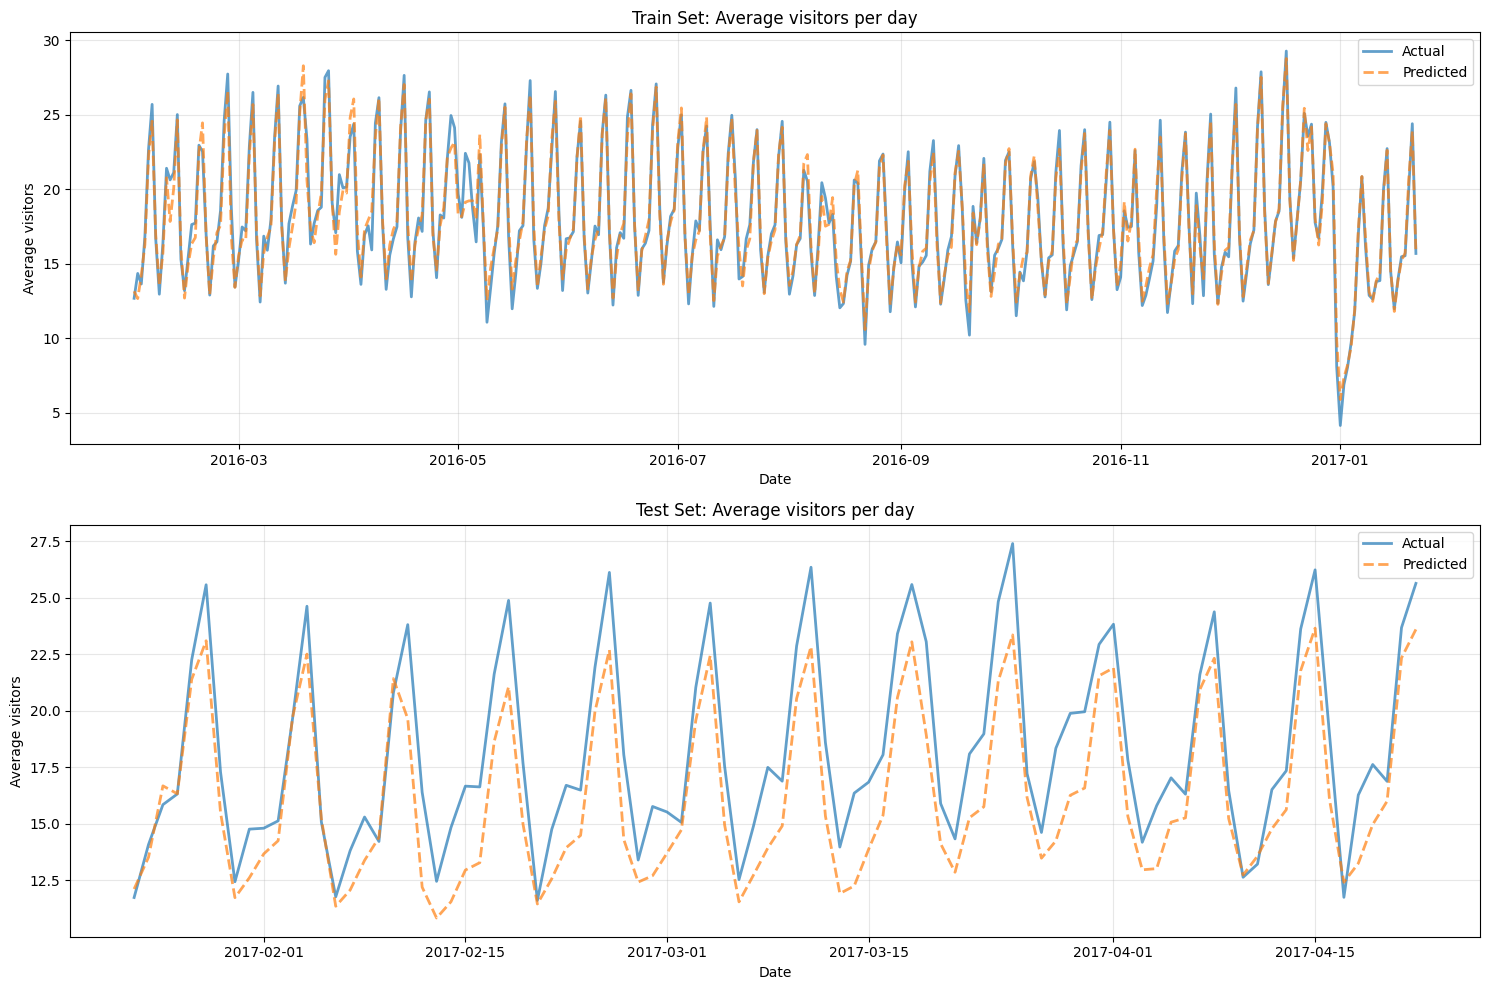

In [23]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [5]:
model_shap = joblib.load(MODEL_PATH)

In [8]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [9]:
test_labels, temp_features = recursive_predict(
    model_shap,
    test_features,
    X,
    y,
    drop_cols=DROP_COLUMNS,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:154: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00000000e+00 0.00000000e+00 1.00175954e+01 4.64652231e+00
 2.32238536e+01 2.64597602e+01 2.75946748e+01 0.00000000e+00
 3.79930726e+01 1.83460491e+00 2.01408804e+01 4.08508591e+00
 2.84289717e+01 5.14789637e+01 2.32535656e+01 4.28271024e+00
 1.39447304e+01 9.67558775e+00 1.77651820e+01 5.13110938e+01
 3.97516524e+00 4.59669150e+00 1.36997593e+01 1.80669744e+01
 9.74708381e-01 2.41913263e+01 1.16000120e+01 1.86249066e+01
 6.99476513e-01 1.29114941e+01 2.08750556e+01 3.78732583e+00
 1.76461286e+01 8.55107169e+00 6.78749121e+00 1.57885568e+00
 8.15349074e-01 3.68179727e+01 2.20561627e+01 1.20229661e+01
 3.68381339e+01 3.87253836e+01 5.59912612e+00 1.49763956e-01
 1.40239373e+01 1.59540454e+01 1.31266583e+00 1.16421

In [10]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [28]:
joblib.dump(model_shap, MODEL_PATH)
params_to_save = {
    "cv_splits": CV_SPLITS,
    "test_size": TEST_SIZE,
    "feature_selection_validation_size": FS_VALID_SIZE,
    "first_iteration_n_trials": FIRST_ITER_TRIALS,
    "second_iteration_n_trials": SECOND_ITER_TRIALS,
    "test_score": test_rmsle,
    "cv result": cv_results.sort_values(["rank_test_score"]).iloc[0].to_dict(),
}

PARAMS_PATH = MODELS_DIR / f"{MODEL_NAME}_params.json"
with open(PARAMS_PATH, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)